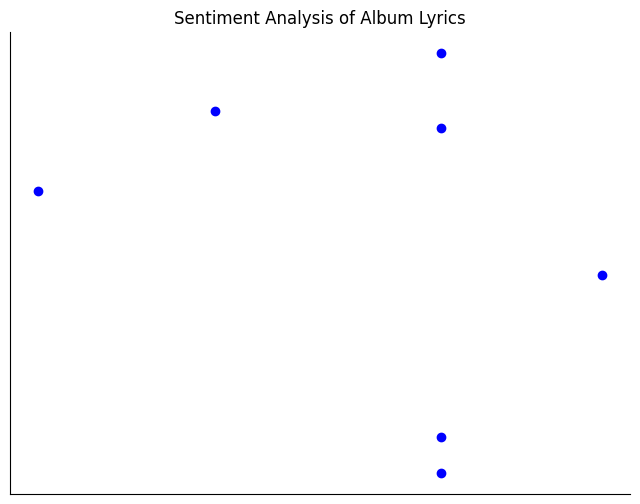

In [ ]:
import os
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

folder_path = ""

def read_lyrics(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        lyrics = file.read()
    return lyrics

album_songs = []

for file_name in os.listdir(folder_path):
    if file_name.endswith(".txt"): 
        song_title = os.path.splitext(file_name)[0] 
        file_path = os.path.join(folder_path, file_name)
        song_lyrics = read_lyrics(file_path)
        album_songs.append({"title": song_title, "lyrics": song_lyrics})


analyzer = SentimentIntensityAnalyzer()


sentiment_data = []
for song in album_songs:
    lyrics = song["lyrics"]
    #sentiment score
    sentiment_score = analyzer.polarity_scores(lyrics)["compound"]
    #word count as a proxy for magnitude
    magnitude = len(lyrics.split())  
    sentiment_data.append((song["title"], sentiment_score, magnitude))


sentiment_data.sort(key=lambda x: x[1])


titles, sentiment_scores, magnitudes = zip(*sentiment_data)
plt.figure(figsize=(8, 6))
plt.scatter(sentiment_scores, magnitudes, color='blue')
plt.title('Sentiment Analysis of Album Lyrics')
plt.xlabel('Sentiment Score')
plt.ylabel('Magnitude')
plt.xticks([])  
plt.yticks([])  
plt.gca().spines['top'].set_visible(False) 
plt.gca().spines['right'].set_visible(False) 



plt.gca().axes.get_yaxis().set_visible(False)
plt.gca().axes.get_xaxis().set_visible(False)


plt.show()


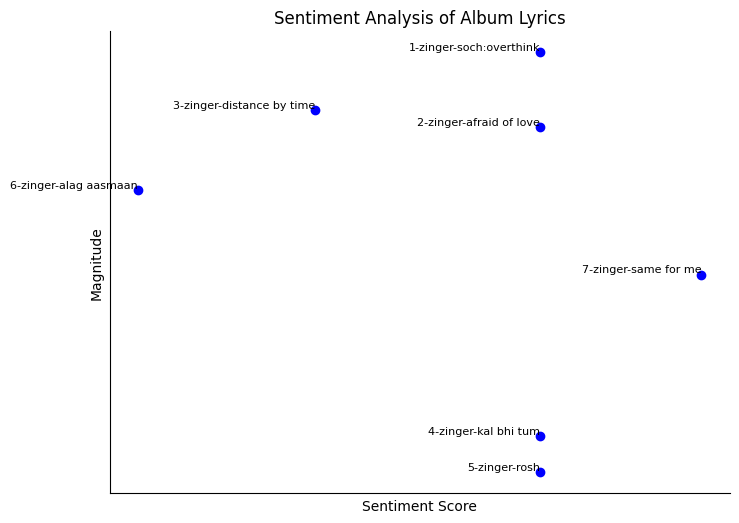

In [1]:
import os
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import make_interp_spline

# Define the folder path where song lyrics are stored
folder_path = "/Users/rosh/Desktop/𝕩 mazedaar circuits /songs:Z0XM sentitment/zoxm/someone/Z0XM"


# Function to read lyrics from a text file
def read_lyrics_from_file(file_path):
    with open(file_path, "r", encoding="utf-8") as file:
        lyrics = file.read()
    return lyrics

# List to store song data
album_songs = []

# Loop through files in the folder
for file_name in os.listdir(folder_path):
    if file_name.endswith(".txt"):  # Assuming lyrics files have .txt extension
        song_title = os.path.splitext(file_name)[0]  # Extract song title from file name
        file_path = os.path.join(folder_path, file_name)
        song_lyrics = read_lyrics_from_file(file_path)
        album_songs.append({"title": song_title, "lyrics": song_lyrics})

# Initialize VADER sentiment analyzer
analyzer = SentimentIntensityAnalyzer()

# Analyze song lyrics and calculate sentiment scores and magnitudes
sentiment_data = []
for song in album_songs:
    lyrics = song["lyrics"]
    # Calculate sentiment score
    sentiment_score = analyzer.polarity_scores(lyrics)["compound"]
    magnitude = len(lyrics.split())  # Using word count as a proxy for magnitude
    sentiment_data.append((song["title"], sentiment_score, magnitude))

# Sort sentiment data by sentiment score
sentiment_data.sort(key=lambda x: x[1])

# Scatter plot visualization
titles, sentiment_scores, magnitudes = zip(*sentiment_data)
plt.figure(figsize=(8, 6))
plt.scatter(sentiment_scores, magnitudes, color='blue')
plt.title('Sentiment Analysis of Album Lyrics')
plt.xlabel('Sentiment Score')
plt.ylabel('Magnitude')
plt.xticks([])  # Hide x-axis ticks
plt.yticks([])  # Hide y-axis ticks
plt.gca().spines['top'].set_visible(False)  # Hide top spine
plt.gca().spines['right'].set_visible(False)  # Hide right spine
for i, title in enumerate(titles):
    plt.text(sentiment_scores[i], magnitudes[i], title, fontsize=8, ha='right', va='bottom')


plt.show()
